# Poisson Solver: Comprehensive 2D CPU vs. GPU Benchmark
This notebook benchmarks **4 core solver algorithms** for the 2D Poisson boundary value problem on the unit disk $\Omega = \{ (r, \theta) : 0 \le r < R \}$:
$$\Delta u = f(r, \theta) \quad \text{in } \Omega, \quad u(R, \theta) = g(\theta) \text{ on } \partial\Omega$$

### Evaluated Solvers
1. **Uniform FFT** on Uniform Grid ($N \times M$)
2. **NUDFT (Direct Reference)** on Nonuniform Jittered Mesh
3. **NUFFT Toeplitz** on the SAME Nonuniform Jittered Mesh
4. **NUFFT CG (PCGLS)** on the SAME Nonuniform Jittered Mesh

All three non-uniform solvers (NUDFT, NUFFT Toeplitz, NUFFT CG) are evaluated on the **exact same jittered boundary grid**, providing an apples-to-apples performance and accuracy comparison across both **CPU** and **GPU (CUDA/CuPy)**.


In [1]:
import os
import sys
import platform
import psutil
from pathlib import Path

# Auto-detect Google Colab & Auto-Sync
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('/content/NUFFTRR_Poisson'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git /content/NUFFTRR_Poisson')
    
    # Fetch and hard reset to latest GitHub commit
    os.system('cd /content/NUFFTRR_Poisson && git fetch origin main && git reset --hard origin/main')
    
    if os.getcwd() != '/content/NUFFTRR_Poisson':
        os.chdir('/content/NUFFTRR_Poisson')
        
    os.system('pip install -r requirements.txt -q')
    os.system('pip install cufinufft -q')

# Dynamic repository root resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'CPUvsGPU')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cpu_and_gpu_timing import *

# ---------------------------------------------------------
# System & Hardware Diagnostics Banner (CPU & GPU)
# ---------------------------------------------------------
ram_gb = psutil.virtual_memory().total / (1024 ** 3)
ram_avail_gb = psutil.virtual_memory().available / (1024 ** 3)
cpu_cores_logical = os.cpu_count()
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_model = platform.processor() or "Generic CPU"
if IN_COLAB and os.path.exists('/proc/cpuinfo'):
    with open('/proc/cpuinfo') as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":", 1)[1].strip()
                break

print('=' * 75)
print(f'  BENCHMARK ENVIRONMENT SUMMARY (CPU & GPU)')
print('=' * 75)
print(f'  Environment     : {"Google Colab" if IN_COLAB else "Local Workstation"} ({platform.system()} {platform.release()})')
print(f'  Host CPU        : {cpu_model}')
print(f'  CPU Cores       : {cpu_cores_phys} Physical / {cpu_cores_logical} Logical Threads')
print(f'  System RAM      : {ram_gb:.1f} GB Total ({ram_avail_gb:.1f} GB Available)')

has_gpu = False
try:
    import cupy as cp
    dev = cp.cuda.Device()
    props = cp.cuda.runtime.getDeviceProperties(dev.id)
    gpu_name = props['name'].decode('utf-8') if isinstance(props['name'], bytes) else str(props['name'])
    compute_cap = f"{props['major']}.{props['minor']}"
    free_mem_gb, total_mem_gb = dev.mem_info[0] / (1024**3), dev.mem_info[1] / (1024**3)
    
    print('-' * 75)
    print(f'  GPU Device      : {gpu_name} (Compute Capability: {compute_cap})')
    print(f'  GPU VRAM        : {total_mem_gb:.1f} GB Total ({free_mem_gb:.1f} GB Free)')
    print(f'  CUDA Driver/RT  : {cp.cuda.runtime.runtimeGetVersion()}')
    has_gpu = True
except Exception as e:
    print('-' * 75)
    print(f'  GPU Status      : No CUDA GPU available ({e})')

print('=' * 75)


  BENCHMARK ENVIRONMENT SUMMARY (CPU & GPU)
  Environment     : Google Colab (Linux 6.6.122+)
  Host CPU        : Intel(R) Xeon(R) CPU @ 2.20GHz
  CPU Cores       : 6 Physical / 12 Logical Threads
  System RAM      : 53.0 GB Total (50.6 GB Available)
---------------------------------------------------------------------------
  GPU Device      : NVIDIA L4 (Compute Capability: 8.9)
  GPU VRAM        : 22.0 GB Total (21.0 GB Free)
  CUDA Driver/RT  : 12090


## 1. Problem Setup & Matrix Resolution Grid
Configure domain parameters, resolution study grids, and all numerical solver hyperparameters:

In [2]:
# ---------------------------------------------------------
# 1. Problem Parameters
# --------------------------------------------------------- 
R = 1.0
k = 2
problem = get_benchmark_problem(R=R, k=k)

# ---------------------------------------------------------
# 2. 2D Grid Matrix Resolutions
# ---------------------------------------------------------
N_LIST = [32, 64, 128, 256, 512, 1024]  # Azimuthal points
M_LIST = [32, 64, 128, 256, 512, 1024]  # Radial points

# Fast Perimeter Mode:
# Set PERIMETER_ONLY = True to evaluate boundary rows/cols (min/max N and M)
# for fast 2x2 log-log scaling curves, or False for the full 2D block.
PERIMETER_ONLY = True

# ---------------------------------------------------------
# 3. Numerical Solver Parameters
# ---------------------------------------------------------
QUAD_RULE = 1          # 1: Trapezoidal, 2: Simpson
BC_CHOICE = 1          # 1: Dirichlet, 2: Neumann
NUM_PROCESSORS = 1     # 1 thread recommended for peak CPU cache locality and zero OpenMP lock contention
MAXITER_NUFFT = 100    # Maximum PCGLS iterations
TOL_NUFFT = 1e-8       # Standard PCGLS convergence tolerance (aligns with FINUFFT precision)
REG_PARAM = 1e-10      # Regularization parameter
EPS_FINUFFT = 1e-10    # FINUFFT precision
PRECOND_SHIFT = 1e-3   # Preconditioner diagonal shift (optimal default)
KDE_OVERSAMPLE = 4     # KDE oversampling factor
KDE_BANDWIDTH = 1.0    # KDE bandwidth factor

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True     # True = run each test multiple times and record min runtime
NUM_RUNS = 3           # Number of repetitions per solve (min runtime selected)
set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS)

# ---------------------------------------------------------
# 4. Shared Nonuniform Angular Mesh
# ---------------------------------------------------------
# A single, unified jittered mesh shared by all three nonuniform solvers (NUDFT, Toeplitz, PCGLS)
nonuniform_grid = "jittered"
nonuniform_kwargs = {"jitter_fraction": 0.25}

print(f"Problem: {problem['name']} (k={k}, R={R})")
print(f"Azimuthal Resolutions (N): {N_LIST}")
print(f"Radial Resolutions (M):    {M_LIST}")
print(f"Time Trials: {TIME_TRIALS} (Runs = {NUM_RUNS}) | Perimeter-Only: {PERIMETER_ONLY}")
print(f"Nonuniform Mesh: {nonuniform_grid} (jitter_fraction = {nonuniform_kwargs.get('jitter_fraction', 0.25)})")
print(f"Total Matrix Grid Configurations: {len(N_LIST) * len(M_LIST)} per method (4 methods total)")


Problem: Cartesian Mixed (Dirichlet) (k=2, R=1.0)
Azimuthal Resolutions (N): [32, 64, 128, 256, 512, 1024]
Radial Resolutions (M):    [32, 64, 128, 256, 512, 1024]
Time Trials: True (Runs = 3) | Perimeter-Only: True
Nonuniform Mesh: jittered (jitter_fraction = 0.25)
Total Matrix Grid Configurations: 36 per method (4 methods total)


## 2. Angular Mesh Distributions
Visualizing the underlying angular grids on the unit circle:
1. **Uniform Grid** (Equispaced azimuthal points)
2. **Shared Nonuniform Grid** (Jittered Mesh, $\delta = 0.25$, used identically for NUDFT, NUFFT Toeplitz, and NUFFT CG)


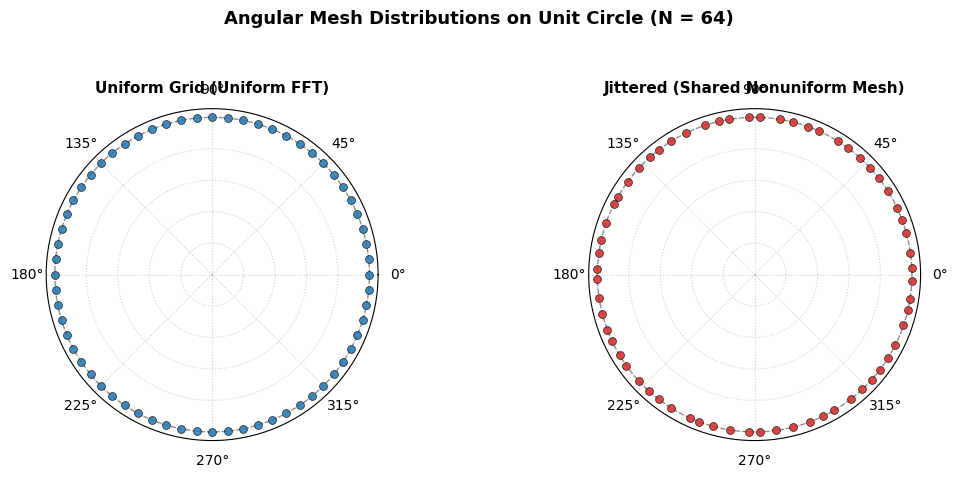

In [3]:
fig_grids = plot_grid_distributions(
    N=64, R=R,
    nonuniform_grid=nonuniform_grid, nonuniform_kwargs=nonuniform_kwargs
)
plt.show()


## 3. Execute 4-Method Benchmark on CPU and GPU
Runs the four solvers (Uniform FFT, NUDFT, NUFFT Toeplitz, NUFFT CG) on **CPU** and **GPU**, collecting execution times and relative errors.


In [4]:
# ---------------------------------------------------------
# 1. Run CPU Benchmark Suite
# ---------------------------------------------------------
print("\n>>> Running CPU Benchmark Suite across all 4 Solvers...")
df_cpu = run_all_benchmarks(
    N_list=N_LIST,
    M_list=M_LIST,
    problem=problem,
    R=R,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    maxiter_nufft=MAXITER_NUFFT,
    tol_nufft=TOL_NUFFT,
    reg_param=REG_PARAM,
    eps_finufft=EPS_FINUFFT,
    precond_shift=PRECOND_SHIFT,
    kde_oversample=KDE_OVERSAMPLE,
    kde_bandwidth=KDE_BANDWIDTH,
    perimeter_only=PERIMETER_ONLY,
    nonuniform_grid=nonuniform_grid,
    nonuniform_kwargs=nonuniform_kwargs,
    num_processors=NUM_PROCESSORS,
    use_gpu=False,
    time_trials=TIME_TRIALS,
    num_runs=NUM_RUNS,
)

# ---------------------------------------------------------
# 2. Run GPU Benchmark Suite (if GPU available)
# ---------------------------------------------------------
df_gpu = pd.DataFrame()
if has_gpu:
    print("\n>>> Running GPU Benchmark Suite across all 4 Solvers...")
    try:
        df_gpu = run_all_benchmarks(
            N_list=N_LIST,
            M_list=M_LIST,
            problem=problem,
            R=R,
            quad_rule=QUAD_RULE,
            BC_choice=BC_CHOICE,
            maxiter_nufft=MAXITER_NUFFT,
            tol_nufft=TOL_NUFFT,
            reg_param=REG_PARAM,
            eps_finufft=EPS_FINUFFT,
            precond_shift=PRECOND_SHIFT,
            kde_oversample=KDE_OVERSAMPLE,
            kde_bandwidth=KDE_BANDWIDTH,
            perimeter_only=PERIMETER_ONLY,
            nonuniform_grid=nonuniform_grid,
            nonuniform_kwargs=nonuniform_kwargs,
            num_processors=None,
            use_gpu=True,
            time_trials=TIME_TRIALS,
            num_runs=NUM_RUNS,
        )
    except Exception as e:
        print(f"Warning: GPU benchmark failed with error: {e}")

# ---------------------------------------------------------
# 3. Combine Benchmark Results
# ---------------------------------------------------------
if not df_gpu.empty:
    df_benchmark = pd.concat([df_cpu, df_gpu], ignore_index=True)
else:
    df_benchmark = df_cpu.copy()



>>> Running CPU Benchmark Suite across all 4 Solvers...


Benchmarking 4 Solvers [CPU]:   0%|          | 0/80 [00:00<?, ?it/s]


>>> Running GPU Benchmark Suite across all 4 Solvers...


Benchmarking 4 Solvers [GPU]:   0%|          | 0/80 [00:00<?, ?it/s]

## 4. Matrix Performance & Accuracy Tables (CPU & GPU)
Formatted $N \times M$ matrix tables in seconds and $L_\infty$ error for each solver configuration across CPU and GPU.

In [5]:
display_benchmark_tables(df_benchmark, N_values=N_LIST, M_values=M_LIST)



TIMING MATRIX (s) [CPU]



ACCURACY MATRIX (L_inf Error) [CPU]



TIMING MATRIX (s) [GPU]



ACCURACY MATRIX (L_inf Error) [GPU]



GPU SPEEDUP FACTOR (CPU Time / GPU Time)


## 5. Consolidated 2x2 Log-Log Runtime Scaling (CPU & GPU)
Comparing execution times (in seconds) across all 4 methods on 2x2 log-log scaling figures for CPU and GPU.


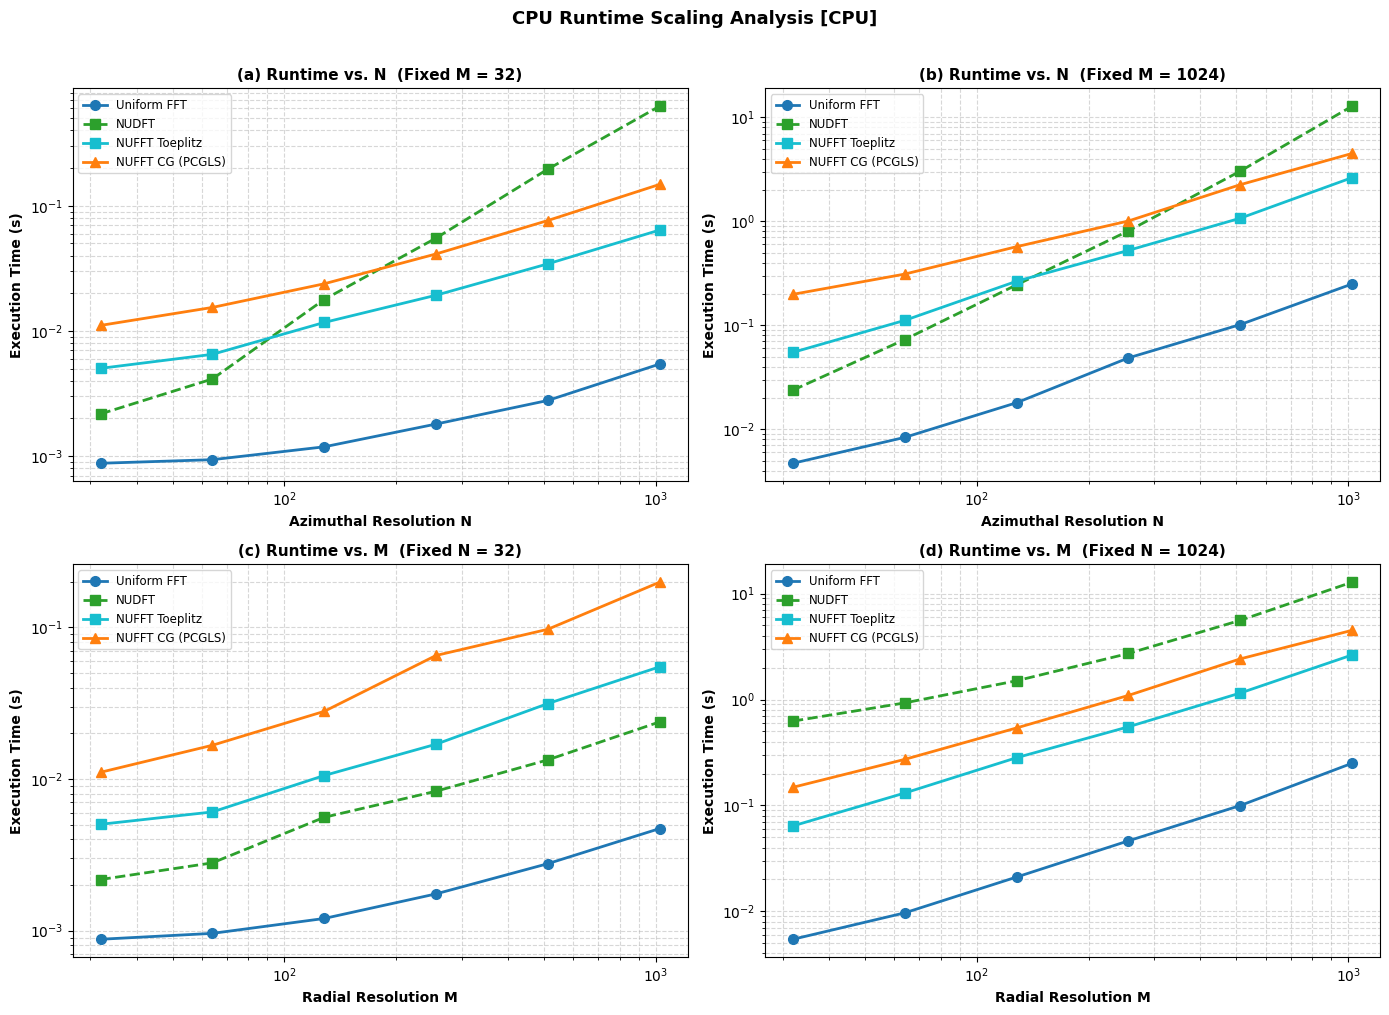

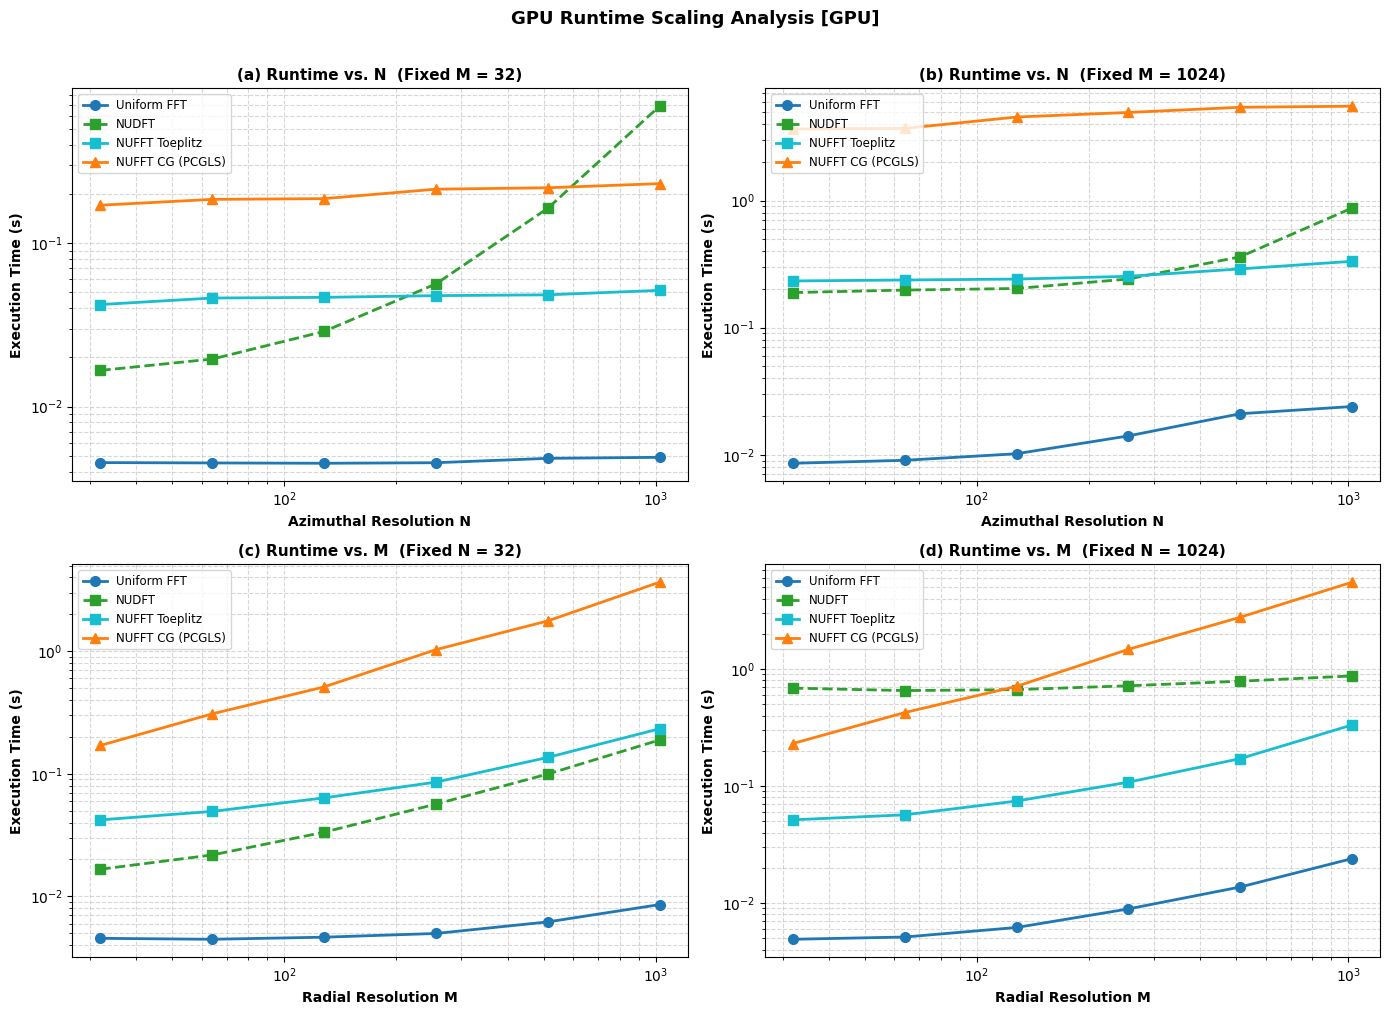

In [6]:
# CPU Runtime Scaling
fig_cpu_runtime = plot_runtime_2x2(
    df_benchmark,
    N_values=N_LIST,
    M_values=M_LIST,
    backend="CPU",
    title="CPU Runtime Scaling Analysis",
)
plt.show()

# GPU Runtime Scaling (if available)
if not df_gpu.empty:
    fig_gpu_runtime = plot_runtime_2x2(
        df_benchmark,
        N_values=N_LIST,
        M_values=M_LIST,
        backend="GPU",
        title="GPU Runtime Scaling Analysis",
    )
    plt.show()


## 6. Consolidated 2x2 Log-Log Accuracy Scaling (CPU & GPU)
Comparing $L_\infty$ error convergence across all 4 methods on 2x2 log-log figures for CPU and GPU.


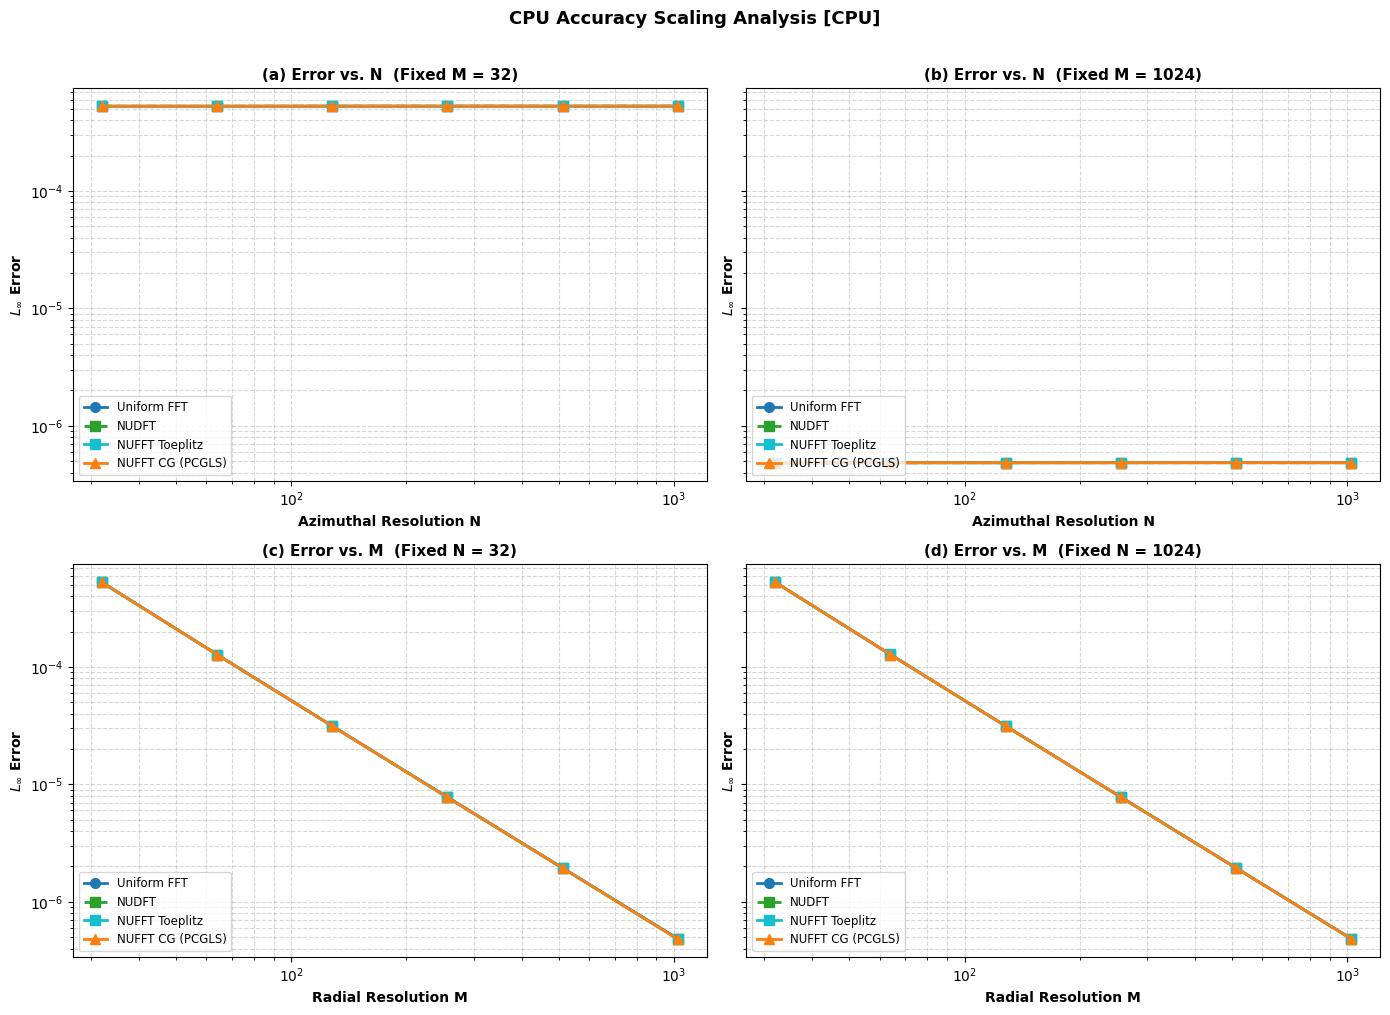

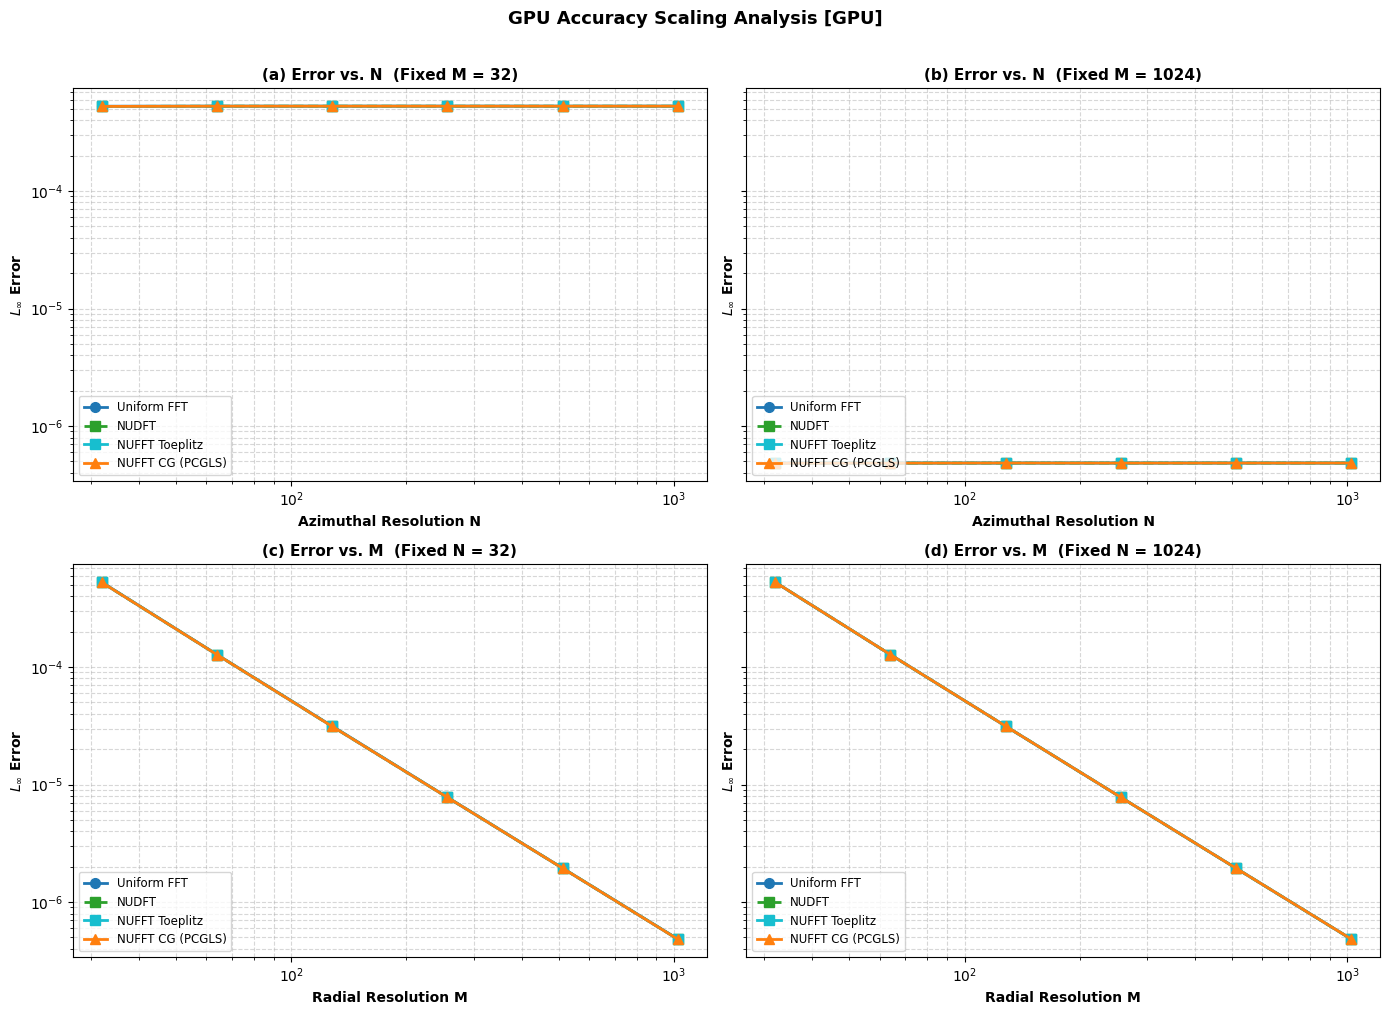

In [7]:
# CPU Accuracy Scaling
fig_cpu_acc = plot_accuracy_2x2(
    df_benchmark,
    N_values=N_LIST,
    M_values=M_LIST,
    metric="L_inf_Error",
    backend="CPU",
    title="CPU Accuracy Scaling Analysis",
)
plt.show()

# GPU Accuracy Scaling (if available)
if not df_gpu.empty:
    fig_gpu_acc = plot_accuracy_2x2(
        df_benchmark,
        N_values=N_LIST,
        M_values=M_LIST,
        metric="L_inf_Error",
        backend="GPU",
        title="GPU Accuracy Scaling Analysis",
    )
    plt.show()


## 7. Side-by-Side Consolidated Runtime Scaling: CPU vs. GPU (4x2 Matrix)
Direct visual comparison of CPU (Column 1) vs. GPU (Column 2) execution times across all 4 boundary slices, with shared row y-axes (`sharey='row'`).
- **Column 0:** CPU Runtimes
- **Column 1:** GPU Runtimes
- **Row 0:** Runtime vs. $N$ (Fixed $M = \min(M)$)
- **Row 1:** Runtime vs. $N$ (Fixed $M = \max(M)$)
- **Row 2:** Runtime vs. $M$ (Fixed $N = \min(N)$)
- **Row 3:** Runtime vs. $M$ (Fixed $N = \max(N)$)


In [ ]:
# ---------------------------------------------------------
# Consolidated 4-Row x 2-Column CPU vs. GPU Runtime Scaling
# Column 0: CPU | Column 1: GPU | Shared Y-Axes along Rows
# ---------------------------------------------------------
if not df_gpu.empty:
    fig_combined_4x2 = plot_cpu_gpu_runtime_combined_4x2(
        df_benchmark,
        N_values=N_LIST,
        M_values=M_LIST,
        title="CPU vs. GPU Runtime Scaling Comparison (Shared Row Y-Axes)",
    )
    plt.show()
else:
    print("[Notice] GPU data not present in this run; skipping combined 4x2 CPU vs. GPU plot.")
